# Exercise 8 (Deep Learning)

There are **3 questions**. Each combines a short conceptual part with a hands-on coding part.

## Setup — Run this cell first

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(42)
np.random.seed(42)


---
## Question 1 — Activation Functions

### 1a — Conceptual

**Answer the following questions in 2–4 sentences each:**

1. A student proposes building a 10-layer MLP using only linear activations (i.e., no non-linearity at all). Why is this equivalent to a single linear layer, regardless of depth? What property of matrix multiplication makes this collapse happen?

2. The **Step function** Θ(x) was historically used as an activation. Explain why it cannot be used in a neural network trained with gradient descent.

3. The lecture showed that **ReLU** largely replaced the Step function and tanh. Name one failure mode specific to ReLU (not shared by ELU or Swish), and explain how ELU resolves it.
> *Write your answers in the Markdown cell below.*

### Your Answers to 1a

**1.** *(write here)*

**2.** *(write here)*

**3.** *(write here)*


---
### 1b — Implementation: Plot Activation Functions and Derivatives

Implement the four activation functions **from scratch using NumPy** (no PyTorch, no `scipy`).
Then plot each function alongside its analytical derivative.

| Activation | Formula |
|---|---|
| Step | $\Theta(x) = 0$ if $x \le 0$ else $1$ |
| ReLU | $\max(0, x)$ |
| ELU  | $x$ if $x>0$, else $\alpha(e^x - 1)$, use $\alpha = 1$ |
| Swish | $x \cdot \sigma(x)$ where $\sigma(x) = 1/(1+e^{-x})$ |

**Tasks:**
1. Fill in the four functions and their derivatives below.
2. Run the provided plotting code — it should produce a 2×4 grid of plots.
3. In a Markdown cell, explain in one sentence why the Swish derivative is non-monotone and why this matters.


In [ ]:
# YOUR CODE HERE

def step(x):
    """Heaviside step function."""
    # TODO
    pass

def step_deriv(x):
    """Derivative of step (returns 0 everywhere, undefined at 0 → return 0)."""
    # TODO
    pass

def relu(x):
    # TODO
    pass

def relu_deriv(x):
    # TODO
    pass

def elu(x, alpha=1.0):
    # TODO
    pass

def elu_deriv(x, alpha=1.0):
    # TODO
    pass

def swish(x):
    # TODO
    pass

def swish_deriv(x):
    # TODO
    pass

In [ ]:
# PLOTTING (do not modify)
z = np.linspace(-3, 3, 500)

funcs   = [step,       relu,       elu,       swish      ]
derivs  = [step_deriv, relu_deriv, elu_deriv, swish_deriv]
names   = ["Step",     "ReLU",     "ELU",     "Swish"    ]
colors  = ["#4e79a7",  "#f28e2b",  "#59a14f", "#b07aa1"  ]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Activation Functions and Their Derivatives", fontsize=14)

for i, (f, df, name, c) in enumerate(zip(funcs, derivs, names, colors)):
    axes[0, i].plot(z, f(z),  color=c, lw=2)
    axes[0, i].set_title(f"φ(z) = {name}")
    axes[0, i].set_ylim(-1.5, 2.0)

    axes[1, i].plot(z, df(z), color=c, lw=2, linestyle="--")
    axes[1, i].set_title(f"dφ/dz [{name}]")
    axes[1, i].set_ylim(-0.5, 1.8)

for ax in axes.flat:
    ax.axhline(0, color="k", lw=0.6)
    ax.axvline(0, color="k", lw=0.6)

plt.tight_layout()
plt.show()


---
## Question 2 — Building & Training an MLP in PyTorch

You will build a small MLP to classify the **two-moons** dataset, a classic non-linearly separable 2D benchmark. The dataset and helper plotting code are provided — **focus on the network and the training loop**.

### 2a — Conceptual

1. In one sentence each, explain what `optimizer.zero_grad()`, `loss.backward()`, and `optimizer.step()` do. Why must `zero_grad()` be called *before* `backward()`, not after?

2. The lecture stated that the **output layer is usually not activated**. For a binary classification task where the loss is `nn.BCEWithLogitsLoss`, explain why applying a sigmoid to the final layer before computing this loss is *doubly wrong* (think numerically and semantically).

> *Write your answers in the Markdown cell below.*


### Your Answers to 2a

**1.** *(write here)*

**2.** *(write here)*


---
### 2b — Dataset & Helper Code (provided, do not modify)


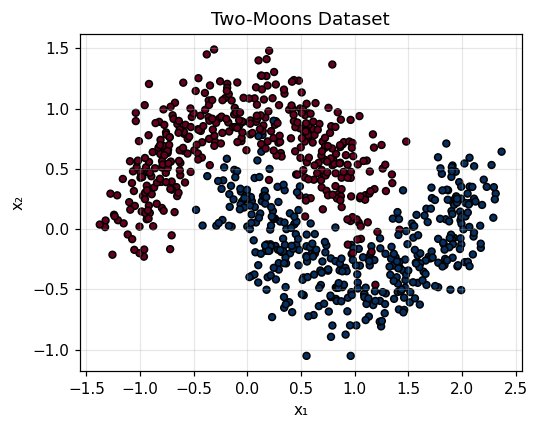

In [2]:
# PROVIDED: Dataset & plotting helper

X_np, y_np = make_moons(n_samples=800, noise=0.20, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)   # shape (N,1)

# Split: 80% train, 20% val
n_train = 640
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plots the binary decision boundary of a trained model."""
    model.eval()
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x1_min.item(), x1_max.item(), h),
                         np.arange(x2_min.item(), x2_max.item(), h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap="RdBu", levels=50)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="RdBu", edgecolors="k", s=20)
    plt.title(title)
    plt.xlabel("x₁"); plt.ylabel("x₂")
    plt.tight_layout(); plt.show()

# Quick look at the data
plt.figure(figsize=(5, 4))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap="RdBu", edgecolors="k", s=20)
plt.title("Two-Moons Dataset"); plt.xlabel("x₁"); plt.ylabel("x₂")
plt.tight_layout(); plt.show()


---
### 2c — Build the MLP

Using `nn.Sequential`, define an MLP with the following architecture:

| Layer | Detail |
|---|---|
| Input | 2 features (x₁, x₂) |
| Hidden 1 | 32 units, ReLU |
| Hidden 2 | 32 units, ReLU |
| Hidden 3 | 16 units, ReLU |
| Output | 1 unit, **no activation** (raw logit) |

Then:
1. Print the model architecture.
2. Count and print the total number of trainable parameters.
3. Verify that the output shape for a batch of 8 samples is `(8, 1)`.


In [ ]:
# YOUR CODE HERE 

model = None  # TODO: define using nn.Sequential

# TODO: print model
# TODO: count parameters
# TODO: verify output shape


---
### 2d — Write the Training Loop (15 pts)

Complete the training loop below. At each epoch you must:
1. Set the model to **training mode**.
2. Compute the forward pass and the **Binary Cross-Entropy loss** (use `nn.BCEWithLogitsLoss`).
3. Zero gradients, call `backward`, and step the optimiser.
4. After each epoch, compute and store the **validation loss** (in `eval` mode, with `torch.no_grad()`).

Use **Adam** with learning rate `1e-3`. Train for **200 epochs**.

Then plot training and validation loss curves.


In [ ]:
# YOUR CODE HERE

loss_fn   = nn.BCEWithLogitsLoss()
optimizer = None   # TODO: use Adam optimizer

train_losses = []
val_losses   = []

n_epochs = 200

for epoch in range(n_epochs):
    #  Training step 
    # TODO

    #  Validation step 
    # TODO

    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

#  Loss curve 
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss", linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.tight_layout(); plt.show()

#  Decision boundary 
plot_decision_boundary(model, X, y, "MLP Decision Boundary (Two Moons)")


---
## Question 3 — Optimizers from Scratch

You will implement four optimizers and, apply them to minimize a challenging 2D loss landscape, and compare their convergence.

### 3a — Conceptual

Using only the lecture formulas, answer:

1. Plain SGD uses a single global learning rate $\gamma$ for all parameters. What is the problem with this when gradients have very different magnitudes across parameters? Which optimizer addresses this, and how?

2. Consider a loss landscape shaped like a long, narrow valley (a classic "banana"). Plain SGD oscillates across the valley walls while making slow progress along the valley floor. Draw (or describe in words) the trajectory of SGD vs SGD+Momentum, and explain *mechanically* why momentum suppresses the oscillations.

3. Adam combines AdaGrad and Momentum. Explain, step by step from the lecture formulas, what the **bias correction** terms $\hat{m}_t = m_t / (1 - \beta_1^t)$ and $\hat{v}_t = v_t / (1 - \beta_2^t)$ correct for. What would happen at step $t=1$ without them (assume $m_0 = v_0 = 0$)?

> *Write your answers in the Markdown cell below.*

---
### 3b — Compare All Four Optimizers using `torch.optim`

Minimize the **Rosenbrock function** — a classic non-convex benchmark with a narrow curved valley and global minimum at $(1, 1)$:

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

**Tasks:**

1. Complete the `run_optimizer` function. It should minimise `rosenbrock_torch` for `N_STEPS` steps using the provided `torch.optim` optimizer. Use the **same training loop pattern** from Q2d: `zero_grad → backward → step`. Record the loss and the (x, y) path at every step.

2. Instantiate all four optimizers from `torch.optim`:

| Optimizer | Class | Key hyperparameters |
|---|---|---|
| SGD | `torch.optim.SGD` | `lr=2e-4` |
| SGD+Momentum | `torch.optim.SGD` | `lr=2e-4, momentum=0.9` |
| AdaGrad | `torch.optim.Adagrad` | `lr=0.5` |
| Adam | `torch.optim.Adam` | `lr=1e-2` |

3. Run the provided plotting code — it will produce a trajectory map and a semi-log convergence curve.

4. In a Markdown cell, answer: based on the convergence plots, which optimizer reaches the lowest loss in 2000 steps? Why does plain SGD barely move compared to the others?

>  **Hint:** `torch.optim` expects a list of `nn.Parameter` or `requires_grad=True` tensors. Make sure to create a **fresh copy** of the starting point for each optimizer and call `.detach().numpy()` to extract values for plotting.


In [ ]:
#  Rosenbrock in PyTorch 

def rosenbrock_torch(params):
    """Scalar Rosenbrock loss using PyTorch tensors (supports autograd)."""
    x, y = params[0], params[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

theta0 = [-1.5, 2.0]   # starting point (Python list → converted per optimizer)
N_STEPS = 2000

# YOUR CODE HERE 

def run_optimizer(opt_class, opt_kwargs, n_steps=N_STEPS):
    """
    Minimize rosenbrock_torch for n_steps using the given torch.optim optimizer.

    Returns:
        losses : list of float, length n_steps
        path   : np.ndarray of shape (n_steps+1, 2)  — parameter trajectory
    """
    # 1. Create a parameter tensor starting at theta0 with requires_grad=True
    params = None  # TODO

    # 2. Instantiate the optimizer (pass [params] as the parameter list)
    optimizer = None  # TODO

    losses, path = [], [None]  # TODO: record initial position

    for _ in range(n_steps):
        # TODO: zero_grad → compute loss → backward → step
        pass

    return losses, np.array(path)


#  Instantiate all four optimizers and run

configs = {
    "SGD":          (torch.optim.SGD,     {"lr": 2e-4}),
    "SGD+Momentum": (torch.optim.SGD,     {"lr": 2e-4, "momentum": 0.9}),
    "AdaGrad":      (torch.optim.Adagrad, {"lr": 0.5}),
    "Adam":         (torch.optim.Adam,    {"lr": 1e-2}),
}

results = {}
for name, (cls, kwargs) in configs.items():
    losses, path = run_optimizer(cls, kwargs)
    results[name] = {"losses": losses, "path": path}

#  Quick check
print(f"{'Optimizer':<16}  {'Final loss':>12}  {'Final θ'}")
print("-" * 50)
for name, r in results.items():
    p = r["path"][-1]
    print(f"  {name:<14}  {r['losses'][-1]:12.4f}  ({p[0]:.4f}, {p[1]:.4f})")


In [ ]:
#  Trajectory plot (Do not modify)
x_grid = np.linspace(-2, 2, 300)
y_grid = np.linspace(-0.5, 3, 300)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z_g = (1 - X_g)**2 + 100*(Y_g - X_g**2)**2

colors_map = {
    "SGD":          "#4e79a7",
    "SGD+Momentum": "#f28e2b",
    "AdaGrad":      "#59a14f",
    "Adam":         "#b07aa1",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, r) in zip(axes, results.items()):
    ax.contourf(X_g, Y_g, np.log1p(Z_g), levels=30, cmap="viridis", alpha=0.7)
    path = r["path"]
    ax.plot(path[:, 0], path[:, 1], color=colors_map[name], lw=1.2, alpha=0.85)
    ax.scatter(path[0, 0],  path[0, 1],  color="white", s=60, zorder=5, label="start")
    ax.scatter(path[-1, 0], path[-1, 1], color="red",   s=60, zorder=5, label="end")
    ax.scatter(1, 1, color="gold", s=80, zorder=6, marker="*", label="optimum (1,1)")
    ax.set_title(name, fontsize=11); ax.set_xlabel("x")
    ax.set_xlim(-2, 2); ax.set_ylim(-0.5, 3)
axes[0].set_ylabel("y")
axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle("Optimizer Trajectories on Rosenbrock Function", fontsize=12)
plt.tight_layout(); plt.show()

# Convergence curves
plt.figure(figsize=(8, 4))
for name, r in results.items():
    plt.semilogy(r["losses"], label=name, color=colors_map[name], lw=1.8)
plt.axhline(1e-4, color="k", lw=0.8, linestyle=":", label="target = 1e-4")
plt.xlabel("Gradient step"); plt.ylabel("Loss  [log scale]")
plt.title("Convergence Comparison — Rosenbrock Function")
plt.legend(); plt.tight_layout(); plt.show()